<a href="https://colab.research.google.com/github/nazipovaalisa/Arrays/blob/master/forecast_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [49]:
moexcons = pd.read_excel('drive/MyDrive/data/индекс-мосбиржи-потребительского-сектора.xlsx')
moexcons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2567 entries, 0 to 2566
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Дата      2567 non-null   datetime64[ns]
 1   Значение  2567 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 40.2 KB


In [50]:
moexcons.rename(columns={'Дата': 'date', 'Значение': 'value'}, inplace=True)

In [51]:
def process_df(df, date_min, date_max):
  # оставляем только дату
  df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d').dt.date

  # диапазон дат от первой до последней вместе с выходными
  full_date_range = pd.date_range(
      start=date_min,
      end=date_max,
      freq='D'
  ).date

  full_df = pd.DataFrame({'date': full_date_range})

  # Объединяем с исходными данными
  df = full_df.merge(
      df,
      on='date',
      how='left'
  )

  # Сортируем по дате
  df.sort_values('date', inplace=True)
  df.reset_index(drop=True, inplace=True)

  print(df.head())
  print(df.tail())
  df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

  print(f"Пропущенных значений: {df['value'].isna().sum()}")
  return df

In [52]:
date_min = moexcons['date'].min()
date_max = moexcons['date'].max()
moexcons = process_df(moexcons, date_min, date_max)

         date    value
0  2015-01-05  5586.76
1  2015-01-06  5738.30
2  2015-01-07      NaN
3  2015-01-08  5756.02
4  2015-01-09  5731.69
            date    value
3734  2025-03-27  8045.67
3735  2025-03-28  7983.33
3736  2025-03-29      NaN
3737  2025-03-30      NaN
3738  2025-03-31  7966.32
Пропущенных значений: 1172


In [53]:
moexcons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3739 entries, 0 to 3738
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3739 non-null   datetime64[ns]
 1   value   2567 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 58.6 KB


In [54]:
# moexcons['date'] = pd.to_datetime(moexcons['date'], format='%Y-%m-%d')
moexcons['day_of_week'] = moexcons['date'].dt.dayofweek + 1  # 1=Пн, 7=Вс
moexcons['month'] = moexcons['date'].dt.month

In [55]:
print(pd.unique(moexcons[np.isnan(moexcons['value'])]['day_of_week']))

[3 6 7 1 5 4 2]


In [56]:
moexcons.head()

,date,value,day_of_week,month
0,2015-01-05,5586.76,1,1
1,2015-01-06,5738.30,2,1
2,2015-01-07,NaN,3,1
3,2015-01-08,5756.02,4,1
4,2015-01-09,5731.69,5,1


In [57]:
moexcons['is_weekend'] = np.where(moexcons['value'].isna(), 1, 0)
print(moexcons.head())
print(moexcons.tail())

        date    value  day_of_week  month  is_weekend
0 2015-01-05  5586.76            1      1           0
1 2015-01-06  5738.30            2      1           0
2 2015-01-07      NaN            3      1           1
3 2015-01-08  5756.02            4      1           0
4 2015-01-09  5731.69            5      1           0
           date    value  day_of_week  month  is_weekend
3734 2025-03-27  8045.67            4      3           0
3735 2025-03-28  7983.33            5      3           0
3736 2025-03-29      NaN            6      3           1
3737 2025-03-30      NaN            7      3           1
3738 2025-03-31  7966.32            1      3           0


In [58]:
moexcons['value'] = moexcons['value'].ffill()
print(moexcons.head())
print(moexcons.tail())

        date    value  day_of_week  month  is_weekend
0 2015-01-05  5586.76            1      1           0
1 2015-01-06  5738.30            2      1           0
2 2015-01-07  5738.30            3      1           1
3 2015-01-08  5756.02            4      1           0
4 2015-01-09  5731.69            5      1           0
           date    value  day_of_week  month  is_weekend
3734 2025-03-27  8045.67            4      3           0
3735 2025-03-28  7983.33            5      3           0
3736 2025-03-29  7983.33            6      3           1
3737 2025-03-30  7983.33            7      3           1
3738 2025-03-31  7966.32            1      3           0


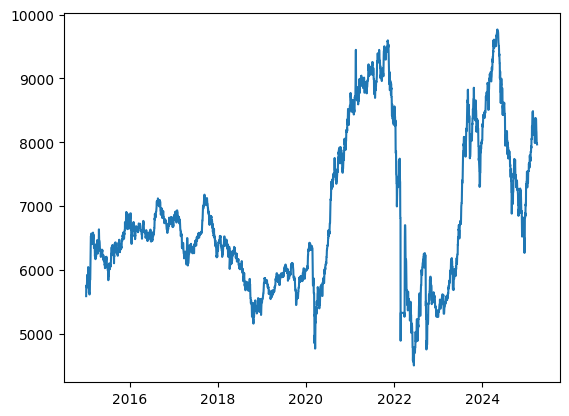

In [59]:
plt.plot(moexcons.date, moexcons.value)
plt.show()

In [60]:
moexcons.set_index('date', inplace=True)

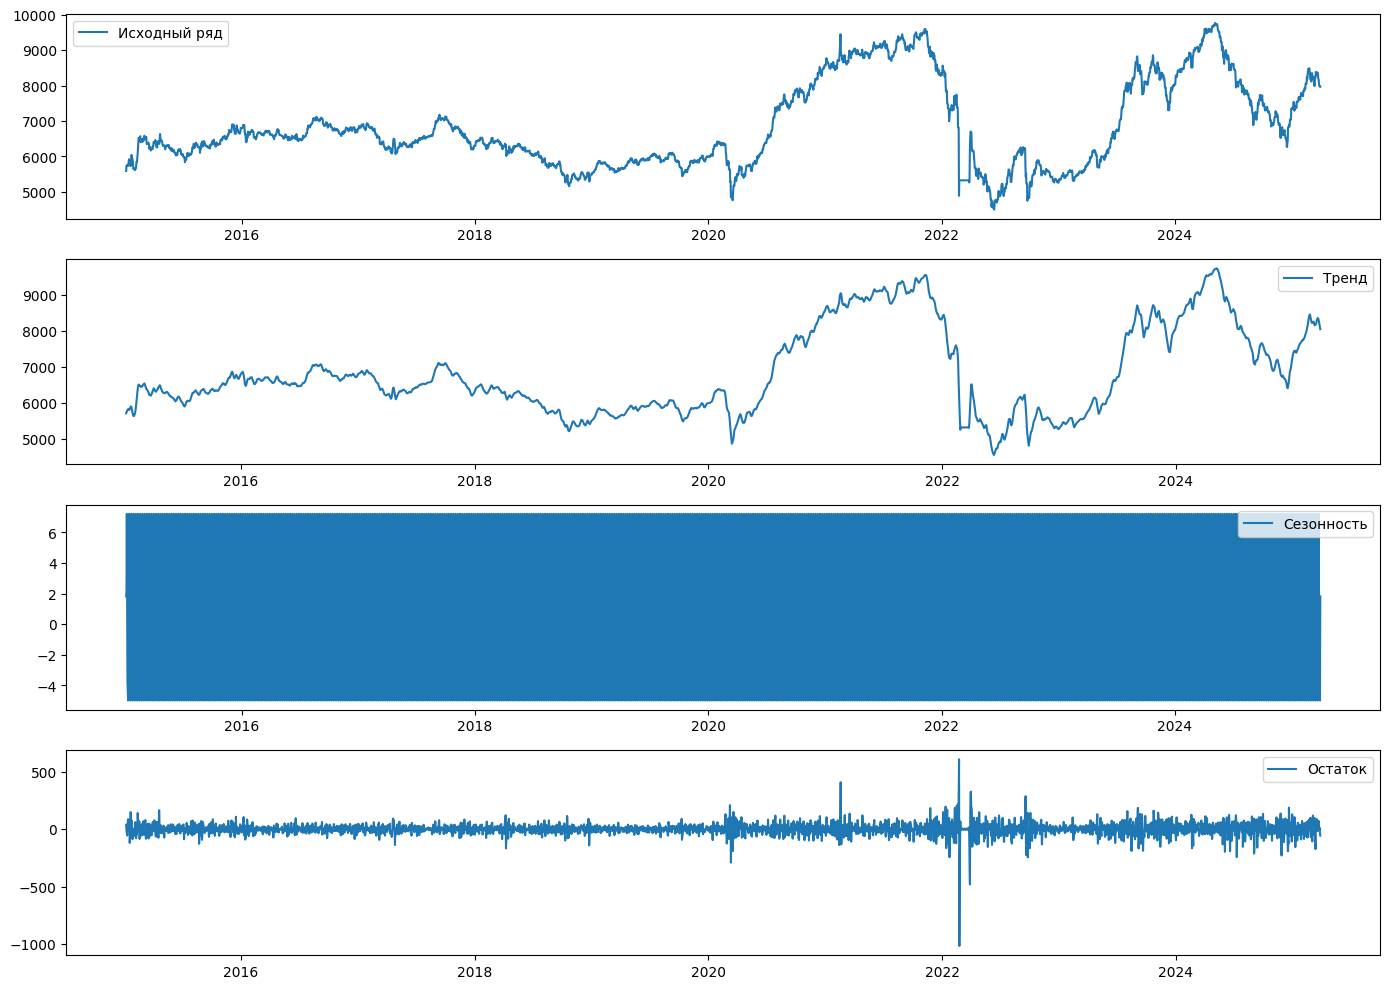

In [61]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Декомпозиция временного ряда
decomposition = seasonal_decompose(moexcons['value'], model='additive')

# Построение графиков компонентов
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(moexcons['value'], label='Исходный ряд')
plt.legend()
plt.subplot(412)
plt.plot(decomposition.trend, label='Тренд')
plt.legend()
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Сезонность')
plt.legend()
plt.subplot(414)
plt.plot(decomposition.resid, label='Остаток')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
tree = ET.parse('drive/MyDrive/data/currencyRate.xml')
root = tree.getroot()

vk_rows = root.findall(".//row[@clearing='vk']")

# Собираем данные
result = []
for row in vk_rows:
    tradedate = datetime.strptime(row.get('tradedate'), '%Y-%m-%d').date()
    rate = float(row.get('rate'))
    result.append({'date': tradedate, 'value': rate})


usd = pd.DataFrame(result)
usd.head()

,date,value
0,2025-03-31,85.4963
1,2025-03-28,83.6813
2,2025-03-27,83.8347
3,2025-03-26,84.2065
4,2025-03-25,84.1930


In [63]:
usd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2587 non-null   object 
 1   value   2587 non-null   float64
dtypes: float64(1), object(1)
memory usage: 40.6+ KB


In [64]:
usd = process_df(usd, date_min, date_max)

         date    value
0  2015-01-05  59.4240
1  2015-01-06  62.6995
2  2015-01-07      NaN
3  2015-01-08  59.6993
4  2015-01-09  60.8113
            date    value
3734  2025-03-27  83.8347
3735  2025-03-28  83.6813
3736  2025-03-29      NaN
3737  2025-03-30      NaN
3738  2025-03-31  85.4963
Пропущенных значений: 1152


In [65]:
usd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3739 entries, 0 to 3738
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3739 non-null   datetime64[ns]
 1   value   2587 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 58.6 KB


In [66]:
usd['value'] = usd['value'].interpolate(method='linear')
usd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3739 entries, 0 to 3738
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3739 non-null   datetime64[ns]
 1   value   3739 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 58.6 KB


In [67]:
tree = ET.parse('drive/MyDrive/data/security.xml')
root = tree.getroot()

rows = root.findall(".//row")

# Собираем данные
result = []
for row in rows:
    tradedate = datetime.strptime(row.get('TRADEDATE'), '%Y-%m-%d').date()
    rvi = float(row.get('LOW'))
    result.append({'date': tradedate, 'value': rvi})

rvi = pd.DataFrame(result)
print(rvi)

            date  value
0     2015-01-05  64.92
1     2015-01-06  71.93
2     2015-01-08  62.72
3     2015-01-09  61.37
4     2015-01-12  65.69
...          ...    ...
2584  2025-04-14  51.98
2585  2025-04-15  58.71
2586  2025-04-16  56.42
2587  2025-04-17  52.38
2588  2025-04-18  50.11

[2589 rows x 2 columns]


In [68]:
rvi = process_df(rvi, date_min, date_max)
rvi.info()
# rvi['date'] = pd.to_datetime(rvi['date'], format='%Y-%m-%d')

         date  value
0  2015-01-05  64.92
1  2015-01-06  71.93
2  2015-01-07    NaN
3  2015-01-08  62.72
4  2015-01-09  61.37
            date  value
3734  2025-03-27  41.39
3735  2025-03-28  38.44
3736  2025-03-29    NaN
3737  2025-03-30    NaN
3738  2025-03-31  39.57
Пропущенных значений: 1164
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3739 entries, 0 to 3738
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3739 non-null   datetime64[ns]
 1   value   2575 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 58.6 KB


In [70]:
rvi['value'] = rvi['value'].ffill()

In [71]:
moexcons['usd'] = usd['value'].values
moexcons['rvi'] = rvi['value'].values

In [72]:
from scipy import stats
stat, p_value = stats.pearsonr(moexcons.rvi, moexcons.usd)
print(stat, p_value)

0.1687258468967925 2.8045073145037118e-25


In [73]:
moexcons.head()

,value,day_of_week,month,is_weekend,usd,rvi
date,,,,,,
2015-01-05,5586.76,1,1,0,59.4240,64.92
2015-01-06,5738.30,2,1,0,62.6995,71.93
2015-01-07,5738.30,3,1,1,61.1994,71.93
2015-01-08,5756.02,4,1,0,59.6993,62.72
2015-01-09,5731.69,5,1,0,60.8113,61.37


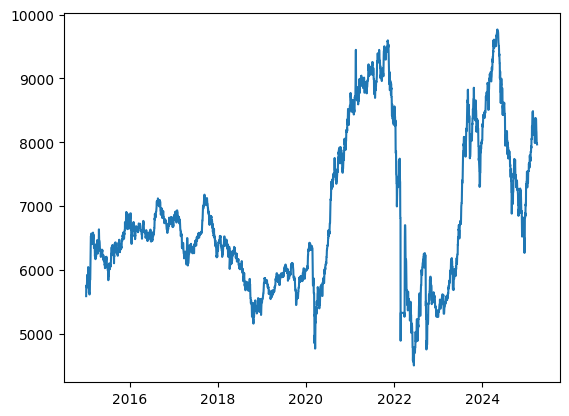

In [74]:
plt.plot(moexcons.index, moexcons.value)
plt.show()

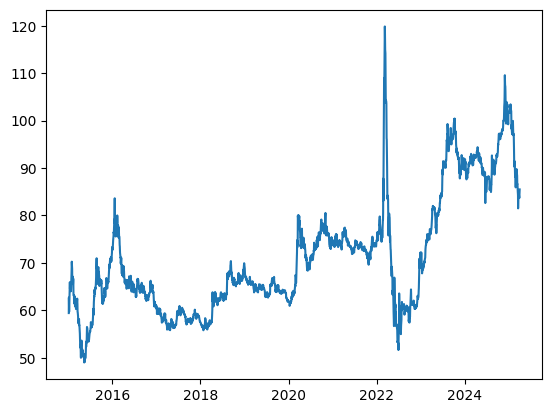

In [75]:
plt.plot(moexcons.index, moexcons.usd)
plt.show()

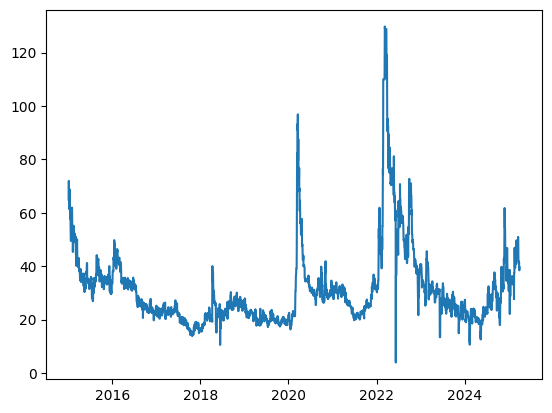

In [76]:
plt.plot(moexcons.index, moexcons.rvi)
plt.show()

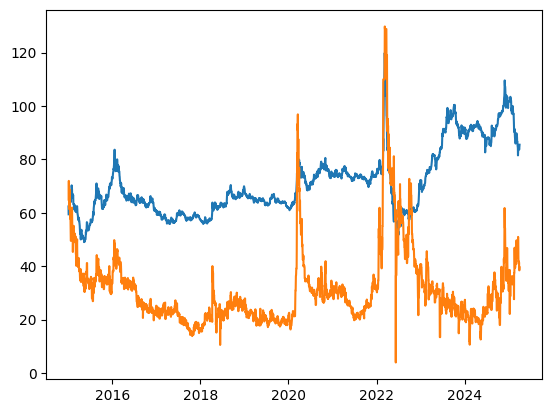

In [ ]:
plt.plot(moexcons.index, moexcons.usd)
plt.plot(moexcons.index, moexcons.rvi)
plt.show()

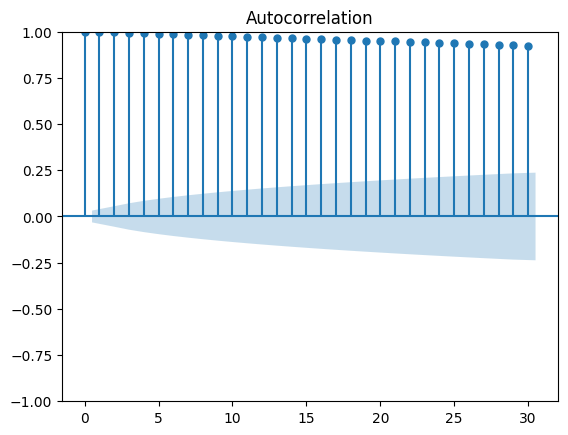

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(moexcons['value'], lags=30)
plt.show()

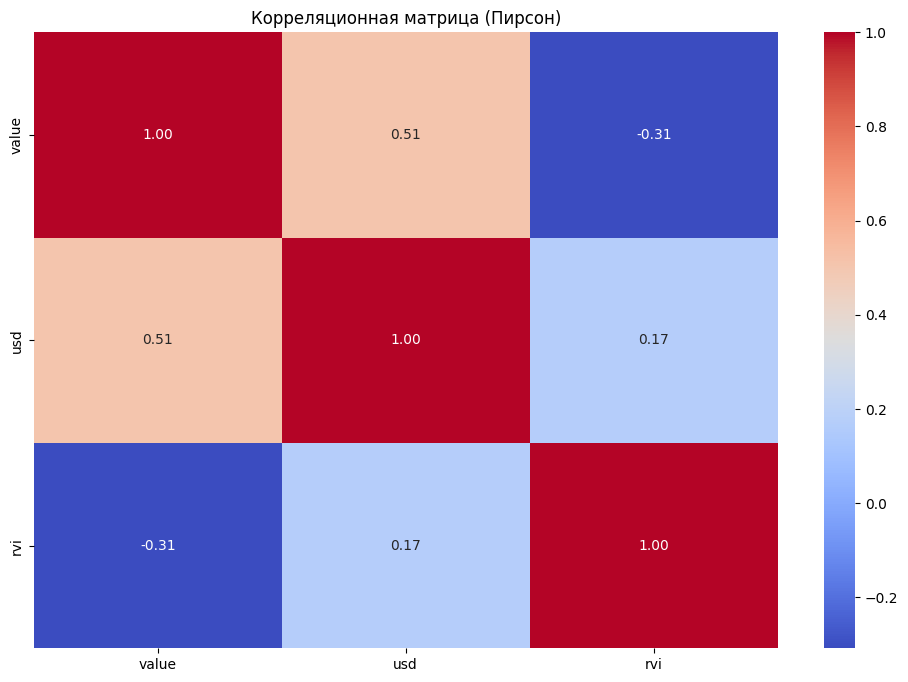

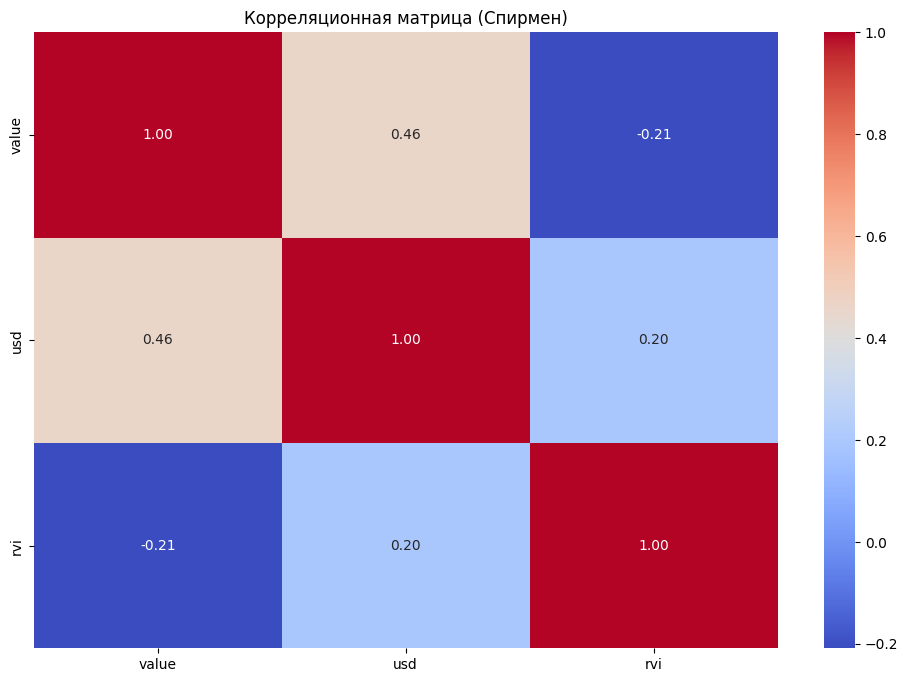

In [77]:
# Оставляем только числовые столбцы
numeric_df = moexcons.select_dtypes(include=['float64'])

# Рассчитываем коэффициенты корреляции
pearson_corr = numeric_df.corr(method='pearson')
spearman_corr = numeric_df.corr(method='spearman')

# Визуализация
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица (Пирсон)')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица (Спирмен)')
plt.show()

In [169]:
from statsmodels.tsa.stattools import adfuller

# Функция для проверки на стационарность
def check_stationarity(series):
    result = adfuller(series)
    p_value = result[1]
    return p_value

non_stationary_features = []

# Преобразование в стационарный вид
for feature in ['value', 'usd', 'rvi']:
    p_value = check_stationarity(moexcons[feature])
    if p_value > 0.05:  # Если p-value > 0.05, данные не стационарны
        print(f"{feature} не стационарен")
        # moexcons[feature] = moexcons[feature].diff().dropna()  # Дифференцируем данные
        non_stationary_features.append(feature)
    else:
        print(f"{feature} стационарен.")
moexcons.dropna(inplace=True)

value не стационарен
usd не стационарен
rvi стационарен.


#todo
попробовать привести ряды к стационарным

In [170]:
lags = np.arange(1, 8, 1)
for key in (['value', 'usd', 'rvi']):
    for lag in lags:
        moexcons[f'{key}_lag_{lag}'] = moexcons[key].shift(lag)

moexcons.dropna(inplace=True)

In [171]:
moexcons.head()

,value,day_of_week,month,is_weekend,usd,rvi,log_value,log_usd,value_lag_1,value_lag_2,...,usd_lag_5,usd_lag_6,usd_lag_7,rvi_lag_1,rvi_lag_2,rvi_lag_3,rvi_lag_4,rvi_lag_5,rvi_lag_6,rvi_lag_7
date,,,,,,,,,,,,,,,,,,,,,
2015-01-12,5799.07,1,1,0,63.2585,65.69,8.665453,4.147230,5731.69,5731.69,...,61.199400,62.699500,59.4240,61.37,61.37,61.37,62.72,71.93,71.93,64.92
2015-01-13,5878.11,2,1,0,65.6135,64.26,8.678991,4.183781,5799.07,5731.69,...,59.699300,61.199400,62.6995,65.69,61.37,61.37,61.37,62.72,71.93,71.93
2015-01-14,5920.55,3,1,0,65.9389,68.72,8.686185,4.188729,5878.11,5799.07,...,60.811300,59.699300,61.1994,64.26,65.69,61.37,61.37,61.37,62.72,71.93
2015-01-15,5838.96,4,1,0,64.5606,65.29,8.672308,4.167604,5920.55,5878.11,...,61.627033,60.811300,59.6993,68.72,64.26,65.69,61.37,61.37,61.37,62.72
2015-01-16,5808.06,5,1,0,65.2554,59.65,8.667002,4.178309,5838.96,5920.55,...,62.442767,61.627033,60.8113,65.29,68.72,64.26,65.69,61.37,61.37,61.37


In [79]:
moexcons.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3739 entries, 2015-01-05 to 2025-03-31
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   value        3739 non-null   float64
 1   day_of_week  3739 non-null   int32  
 2   month        3739 non-null   int32  
 3   is_weekend   3739 non-null   int64  
 4   usd          3739 non-null   float64
 5   rvi          3739 non-null   float64
dtypes: float64(3), int32(2), int64(1)
memory usage: 175.3 KB


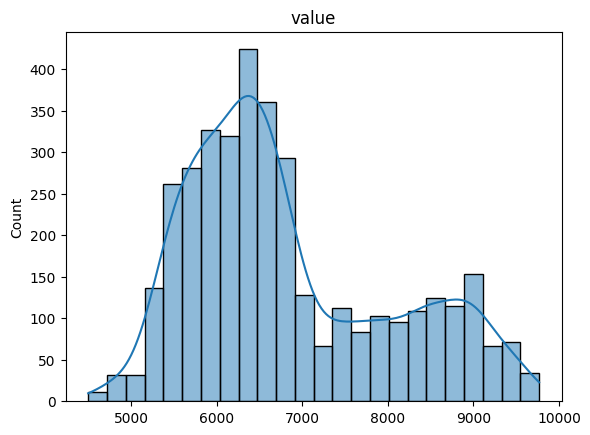

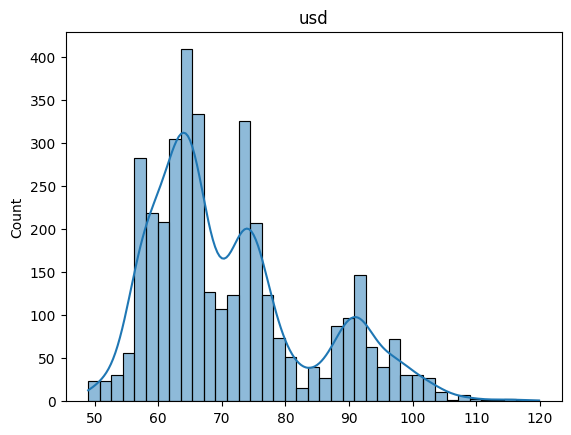

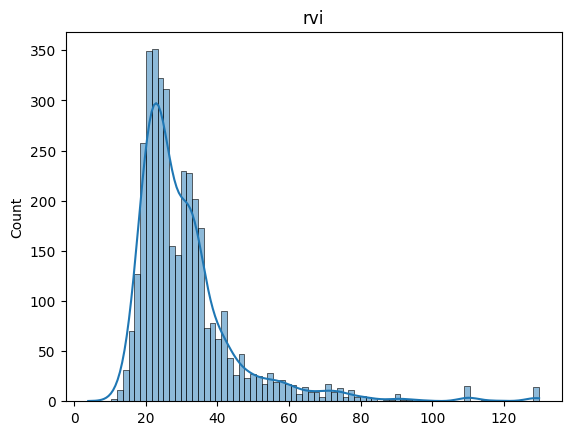

In [97]:
import seaborn as sns

rational_columns = ['value', 'usd', 'rvi']
for feature in rational_columns:
  sns.histplot(moexcons[feature].values, kde=True)
  plt.title(feature)
  plt.show()

In [104]:
# def safe_log(series):
#     return np.log(series + 1e-10)  # Малое значение вместо нуля

# # Обратное преобразование
# def inverse_log(series):
#     return np.exp(series) - 1e-10

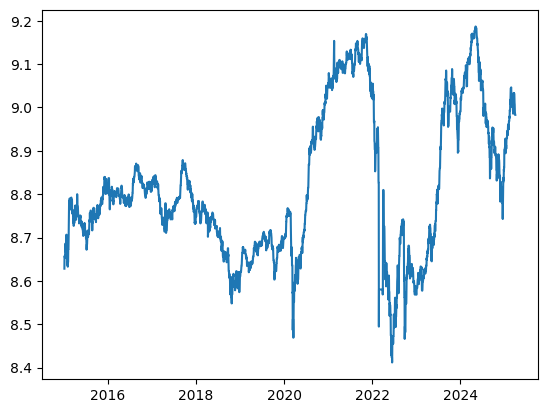

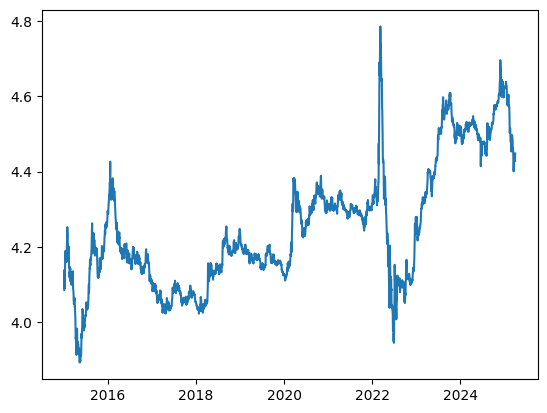

In [106]:
# for column in ['value', 'usd']:
#   log_column = safe_log(moexcons[column])
#   moexcons[f'log_{column}'] = log_column
#   plt.plot(moexcons.index, log_column)
#   plt.show()

In [172]:
# === 1. Конфигурация признаков ===
categorical_features = ['is_weekend', 'month', 'day_of_week']
target = 'value'
features = list(moexcons.columns)
features_to_scale = [f for f in features if f not in categorical_features and f != target]
final_features = [f for f in features if f != target]

# === 2. Деление на X и y ===
X_raw = moexcons[final_features].copy()
y_raw = moexcons[target].copy()

# === 3. Разделение на train/val/test ===
train_size = int(len(X_raw) * 0.8)
val_size = int(len(X_raw) * 0.1)

X_train_raw = X_raw.iloc[:train_size]
y_train_raw = y_raw.iloc[:train_size]

X_val_raw = X_raw.iloc[train_size:train_size + val_size]
y_val_raw = y_raw.iloc[train_size:train_size + val_size]

X_test_raw = X_raw.iloc[train_size + val_size:]
y_test_raw = y_raw.iloc[train_size + val_size:]


In [173]:
# === 4. Масштабирование только числовых признаков ===
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler_X.fit_transform(X_train_raw[features_to_scale]),
    columns=features_to_scale,
    index=X_train_raw.index
)
X_val_scaled = pd.DataFrame(
    scaler_X.transform(X_val_raw[features_to_scale]),
    columns=features_to_scale,
    index=X_val_raw.index
)
X_test_scaled = pd.DataFrame(
    scaler_X.transform(X_test_raw[features_to_scale]),
    columns=features_to_scale,
    index=X_test_raw.index
)

# Объединяем с категориальными признаками
X_train = pd.concat([X_train_scaled, X_train_raw[categorical_features]], axis=1)
X_val = pd.concat([X_val_scaled, X_val_raw[categorical_features]], axis=1)
X_test = pd.concat([X_test_scaled, X_test_raw[categorical_features]], axis=1)

In [174]:
X_train

,usd,rvi,log_value,log_usd,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_5,value_lag_6,...,rvi_lag_1,rvi_lag_2,rvi_lag_3,rvi_lag_4,rvi_lag_5,rvi_lag_6,rvi_lag_7,is_weekend,month,day_of_week
date,,,,,,,,,,,,,,,,,,,,,
2015-01-12,-0.383494,2.102122,-0.726282,-0.353640,-0.774221,-0.774304,-0.774400,-0.752328,-0.768577,-0.768674,...,1.831391,1.829697,1.828042,1.910170,2.479173,2.475779,2.038826,0,1,1
2015-01-13,-0.084427,2.013043,-0.639845,-0.030868,-0.712810,-0.774304,-0.774400,-0.774506,-0.752424,-0.768674,...,2.100346,1.829697,1.828042,1.826267,1.907354,2.475779,2.473309,0,1,2
2015-01-14,-0.043104,2.290870,-0.593912,0.012817,-0.640772,-0.712890,-0.774400,-0.774506,-0.774603,-0.752520,...,2.011317,2.098503,1.828042,1.826267,1.823537,1.904548,2.473309,0,1,3
2015-01-15,-0.218138,2.077205,-0.682513,-0.173720,-0.602092,-0.640849,-0.712983,-0.774506,-0.774603,-0.774700,...,2.288988,2.009523,2.096697,1.826267,1.823537,1.820817,1.902469,0,1,4
2015-01-16,-0.129903,1.725872,-0.716392,-0.079195,-0.676454,-0.602167,-0.640938,-0.713086,-0.774603,-0.774700,...,2.075443,2.287040,2.007767,2.094758,1.823537,1.820817,1.818795,0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-11,1.194986,-0.050726,-1.010018,1.230490,-0.942541,-0.910512,-0.937986,-0.938101,-0.961169,-0.990849,...,-0.051293,-0.277192,0.165737,0.164978,0.326006,0.476159,0.475057,1,3,6
2023-03-12,1.147051,-0.050726,-1.010018,1.186341,-0.942541,-0.942631,-0.910614,-0.938101,-0.938206,-0.961276,...,-0.051293,-0.051942,-0.277668,0.164978,0.163960,0.324823,0.475057,1,3,7
2023-03-13,1.099116,-0.056333,-1.014175,1.141970,-0.942541,-0.942631,-0.942735,-0.910727,-0.938206,-0.938312,...,-0.051293,-0.051942,-0.052545,-0.278156,0.163960,0.162943,0.323824,0,3,1


In [175]:
# Масштабируем целевую переменную
y_train = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten()
y_val = scaler_y.transform(y_val_raw.values.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test_raw.values.reshape(-1, 1)).flatten()

In [115]:
y_train

array([-0.96319377, -0.79224752, -0.79224752, ..., -1.00880204,
       -1.01296025, -0.984678  ])

<ipython-input-122-71d9f112ba41>:4: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



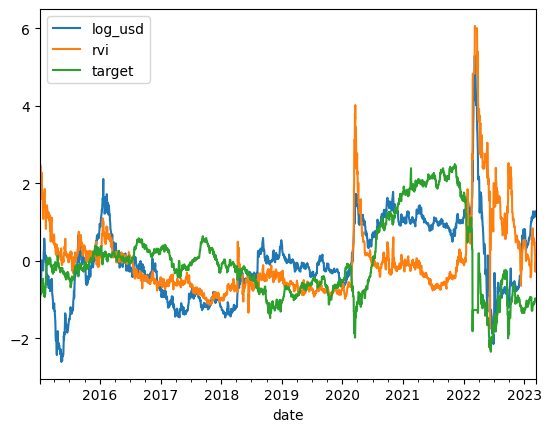

In [122]:
for feature in final_features:
  if feature not in categorical_features:
    X_train[feature].plot(label=feature)
plt.plot(X_train.index, y_train, label='target')
plt.legend()
plt.show()

In [123]:
import plotly.graph_objects as go

# Создание фигуры
fig = go.Figure()

# Добавление линии с данными
fig.add_trace(go.Scatter(
    x=X_train.index,  # Используем индекс как значения по X
    y=y_train,        # Значения по Y
    mode='lines',     # Режим отображения - линии
    name='Индекс'     # Название для легенды
))

# Настройка макета
fig.update_layout(
    title='График MOEXCONS',  # Заголовок графика
    xaxis_title='Дата',   # Название оси X
    yaxis_title='Индекс', # Название оси Y
    showlegend=True         # Показывать легенду
)

fig.show()

In [199]:
# 6. Создание окон последовательностей ===
X_all = np.concatenate([X_train.values, X_val.values, X_test.values], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

def create_sequences(X, y, sequence_length):
    Xs, ys = [], []
    for i in range(sequence_length, len(X)):
        Xs.append(X[i-sequence_length:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

sequence_length = 7
X_seq, y_seq = create_sequences(X_all, y_all, sequence_length)

In [200]:
X_seq.shape

(3725, 7, 28)

In [186]:
y_seq.shape

(3718,)

In [207]:
# === 7. Разделение обратно на train / val / test ===
n_train = len(y_train) - sequence_length
n_val = len(y_val)
n_test = len(y_test)

X_train_seq = X_seq[:n_train]
y_train_seq = y_seq[:n_train]

X_val_seq = X_seq[n_train:n_train + n_val]
y_val_seq = y_seq[n_train:n_train + n_val]

X_test_seq = X_seq[n_train + n_val:]
y_test_seq = y_seq[n_train + n_val:]

In [218]:
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [219]:
# 6. Обучение с ранней остановкой
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.1819 - val_loss: 0.0723
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0371 - val_loss: 0.0977
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0293 - val_loss: 0.1769
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0268 - val_loss: 0.0582
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0243 - val_loss: 0.1389
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0207 - val_loss: 0.0696
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0196 - val_loss: 0.0366
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0235 - val_loss: 0.0633
Epoch 9/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0172 - val_loss: 0.0207
Epoch 10/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0182 - val_loss: 0.0382
Epoch 11/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0179 - val_loss: 0.0392
Epoch 12/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 

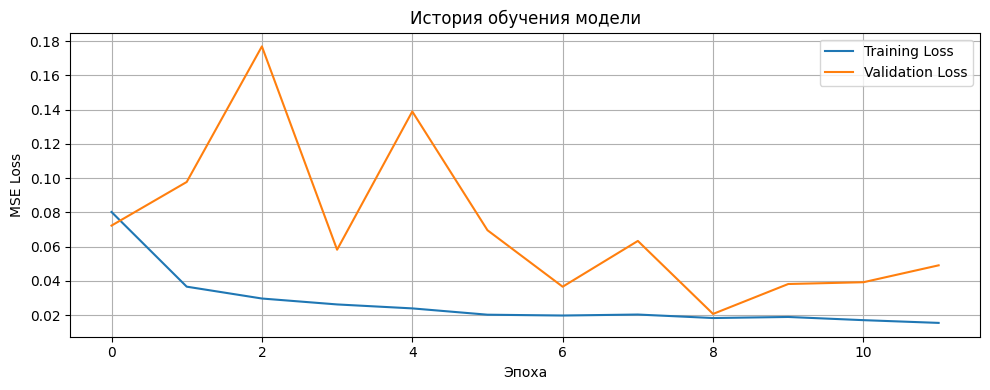

In [220]:
# === 12. Визуализация истории обучения ===
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('История обучения модели')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
MSE: 24974.8534
RMSE: 158.0343
MAE: 118.9021
R²: 0.9795


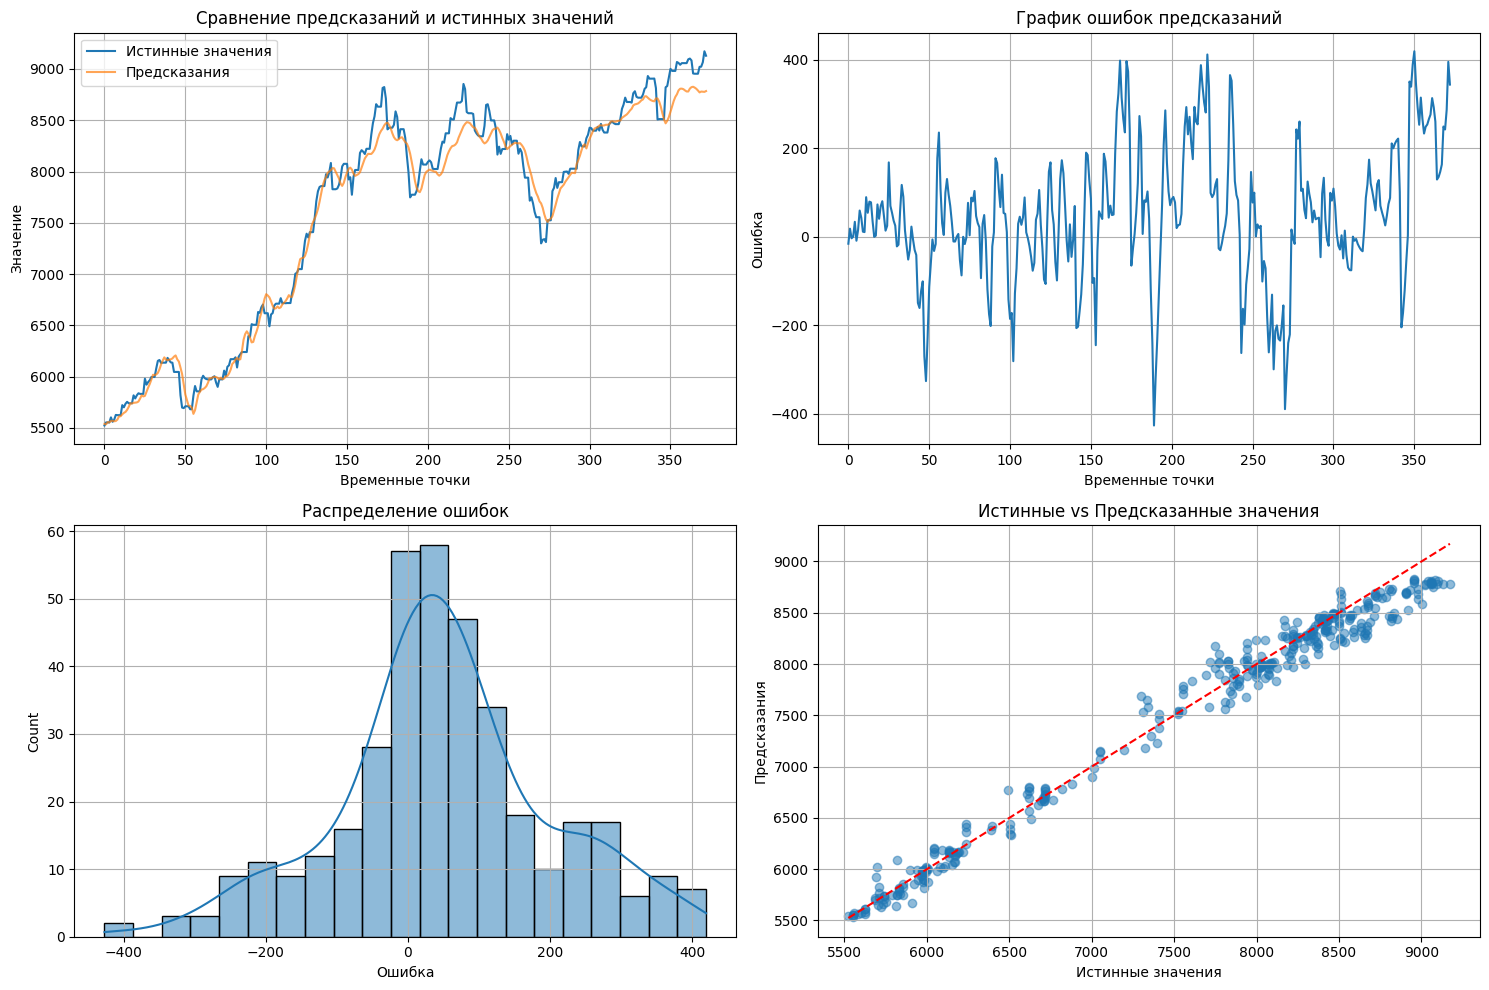

In [221]:
# Предсказания на валидационной выборке
y_val_pred_scaled = model.predict(X_val_seq).flatten()

# Обратное преобразование масштабирования
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
y_val_true = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()

# # Обратное логарифмирование
# y_val_pred = inverse_log(y_val_pred_log)
# y_val_true = inverse_log(y_val_true_log)

mse = mean_squared_error(y_val_true, y_val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_true, y_val_pred)
r2 = r2_score(y_val_true, y_val_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(15, 10))

# График предсказаний vs истинных значений
plt.subplot(2, 2, 1)
plt.plot(y_val_true, label='Истинные значения')
plt.plot(y_val_pred, label='Предсказания', alpha=0.7)
plt.title('Сравнение предсказаний и истинных значений')
plt.xlabel('Временные точки')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)

# График ошибок
plt.subplot(2, 2, 2)
errors = y_val_true - y_val_pred
plt.plot(errors)
plt.title('График ошибок предсказаний')
plt.xlabel('Временные точки')
plt.ylabel('Ошибка')
plt.grid(True)

# Гистограмма распределения ошибок
plt.subplot(2, 2, 3)
sns.histplot(errors, kde=True)
plt.title('Распределение ошибок')
plt.xlabel('Ошибка')
plt.grid(True)

# График истинные vs предсказанные значения
plt.subplot(2, 2, 4)
plt.scatter(y_val_true, y_val_pred, alpha=0.5)
plt.plot([min(y_val_true), max(y_val_true)], [min(y_val_true), max(y_val_true)], 'r--')
plt.title('Истинные vs Предсказанные значения')
plt.xlabel('Истинные значения')
plt.ylabel('Предсказания')
plt.grid(True)

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Метрики для валидационной выборки:
R²: 0.9795 | MSE: 24974.8534 | MAE: 118.9021 | RMSE: 158.0343

Метрики для тестовой выборки:
R²: 0.9105 | MSE: 73522.0040 | MAE: 206.0158 | RMSE: 271.1494



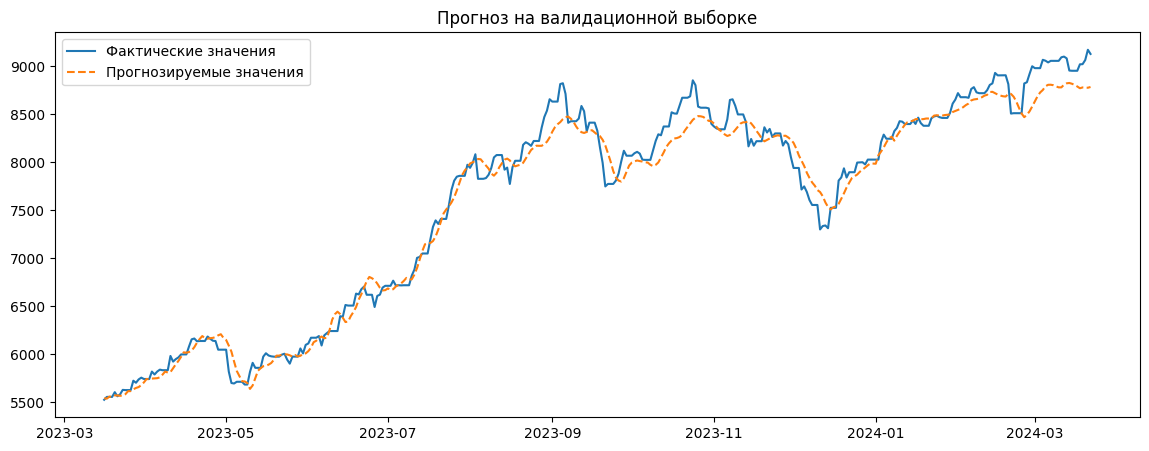

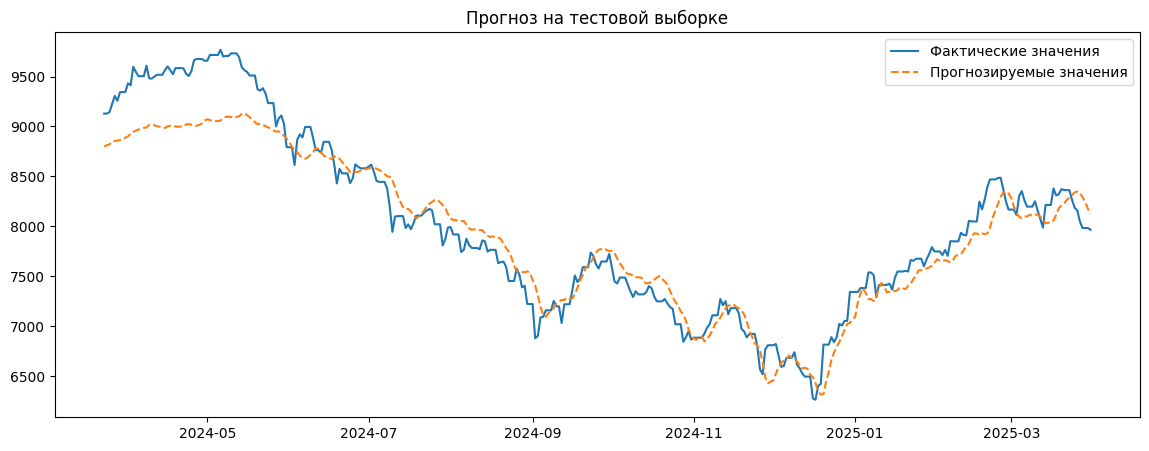

In [222]:


# === 9. Прогнозы ===
val_preds = model.predict(X_val_seq).flatten()
test_preds = model.predict(X_test_seq).flatten()

# Обратное масштабирование
y_val_real = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()
val_preds_real = scaler_y.inverse_transform(val_preds.reshape(-1, 1)).flatten()

y_test_real = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
test_preds_real = scaler_y.inverse_transform(test_preds.reshape(-1, 1)).flatten()

# === 10. Метрики ===
def print_metrics(y_true, y_pred, label=''):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f'Метрики для {label}:')
    print(f'R²: {r2:.4f} | MSE: {mse:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}\n')

print_metrics(y_val_real, val_preds_real, 'валидационной выборки')
print_metrics(y_test_real, test_preds_real, 'тестовой выборки')

# === 11. Визуализация ===
plt.figure(figsize=(14,5))
plt.plot(X_val_raw.index, y_val_real, label="Фактические значения")
plt.plot(X_val_raw.index, val_preds_real, label="Прогнозируемые значения", linestyle='--')
plt.title('Прогноз на валидационной выборке')
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(X_test_raw.index, y_test_real, label="Фактические значения")
plt.plot(X_test_raw.index, test_preds_real, label="Прогнозируемые значения", linestyle='--')
plt.title('Прогноз на тестовой выборке')
plt.legend()
plt.show()


In [213]:
from tensorflow.keras.models import save_model

# Сохраняем всю модель (архитектура + веса + оптимизатор)
save_model(model, 'drive/MyDrive/my_lstm_model.keras')  # или .h5

# В Colab файл появится в файловой системе слева (панель файлов)